In [3]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the data

In [5]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [6]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [9]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    
    prediction = tx @ w

    error = y - prediction

    return np.mean(error**2)


# 2. Grid Search

Fill in the function `grid_search()` below:

In [12]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))

    W0, W1 = np.meshgrid(grid_w0, grid_w1)

    for i in range(len(grid_w0)):
        for j in range(len(grid_w1)):
            w = np.array([W0[i, j], W1[i, j]])
            losses[i, j] = compute_loss(y, tx, w)


    return losses

Let us play with the grid search demo now!

Grid Search: loss*=84.84896629356496, w0*=66.66666666666669, w1*=16.666666666666686, execution time=0.006 seconds


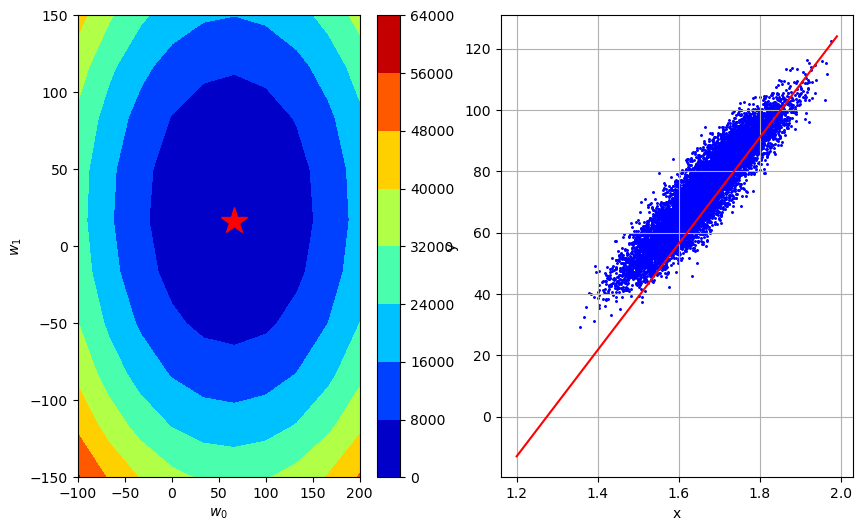

In [84]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=10)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [17]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """

    N = y.shape[0]

    return -2/N * tx.T @ (y - tx @ w)


Please fill in the functions `gradient_descent` below:

In [19]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of GD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):

        # Compute loss & Gradient
        loss = compute_loss(y, tx, w)
        gradient = compute_gradient(y, tx, w)

        # Update w
        w = w - gamma * gradient
        
        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [21]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=5584.473425518335, w0=102.61149080294722, w1=18.871597408984524
GD iter. 1/49: loss=919.3640397025624, w0=61.5668944817684, w1=11.322958445390926
GD iter. 2/49: loss=172.94653797204256, w0=77.98473301023992, w1=14.34241403082828
GD iter. 3/49: loss=53.51973769516032, w0=71.4175975988513, w1=13.134631796653363
GD iter. 4/49: loss=34.411449650859026, w0=74.04445176340674, w1=13.61774469032332
GD iter. 5/49: loss=31.354123563770827, w0=72.99371009758457, w1=13.424499532855343
GD iter. 6/49: loss=30.864951389836722, w0=73.41400676391343, w1=13.50179759584253
GD iter. 7/49: loss=30.786683842007267, w0=73.24588809738188, w1=13.470878370647656
GD iter. 8/49: loss=30.774161034354556, w0=73.3131355639945, w1=13.483246060725605
GD iter. 9/49: loss=30.77215738513012, w0=73.28623657734947, w1=13.478298984694426
GD iter. 10/49: loss=30.771836801254214, w0=73.29699617200748, w1=13.480277815106898
GD iter. 11/49: loss=30.771785507834068, w0=73.29269233414428, w1=13.47948628294191


In [22]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 4. Stochastic gradient descent

In [24]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    return compute_gradient(y, tx, w)


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):

        

        for y_batch, tx_batch in batch_iter(y, tx, batch_size, 1, shuffle=True):

            loss = compute_loss(y, tx, w)
            
            gradient = compute_stoch_gradient(y_batch, tx_batch, w)

            w = w - gamma * gradient

            ws.append(w)
            losses.append(loss)

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [25]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=5584.473425518335, w0=11.887284840242087, w1=-10.541004335370138
SGD iter. 1/49: loss=4378.541697428177, w0=22.95004662991296, w1=-15.953059281827825
SGD iter. 2/49: loss=3431.565614162734, w0=31.876639106221134, w1=-20.431475190070156
SGD iter. 3/49: loss=2896.1317443573143, w0=45.501188474244394, w1=-13.117169943804997
SGD iter. 4/49: loss=1510.60196495974, w0=56.994297986974516, w1=-2.383948289683607
SGD iter. 5/49: loss=548.1052503598047, w0=55.52238700899973, w1=0.017649230304451535
SGD iter. 6/49: loss=527.8263774757531, w0=59.27680515487076, w1=-0.24581407953310458
SGD iter. 7/49: loss=415.64141854753245, w0=58.7338696564223, w1=0.3982140644539998
SGD iter. 8/49: loss=413.8924996649954, w0=59.25392859655, w1=-0.1760745380807806
SGD iter. 9/49: loss=414.37370841955527, w0=62.398113048607854, w1=1.2952998520873973
SGD iter. 10/49: loss=297.9503384791433, w0=64.48953054197953, w1=1.3098595218874296
SGD iter. 11/49: loss=256.39440464732013, w0=66.05830353239489,

In [26]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 5. Effect of Outliers and MAE Cost Function

In [69]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)

x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [70]:
y.shape, tx.shape

((10000,), (10000, 2))

In [71]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()

losses, ws = gradient_descent(y, tx, w_initial, max_iters, gamma)

end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=5584.473425518335, w0=102.61149080294722, w1=18.871597408984524
GD iter. 1/49: loss=919.3640397025624, w0=61.5668944817684, w1=11.322958445390926
GD iter. 2/49: loss=172.94653797204256, w0=77.98473301023992, w1=14.34241403082828
GD iter. 3/49: loss=53.51973769516032, w0=71.4175975988513, w1=13.134631796653363
GD iter. 4/49: loss=34.411449650859026, w0=74.04445176340674, w1=13.61774469032332
GD iter. 5/49: loss=31.354123563770827, w0=72.99371009758457, w1=13.424499532855343
GD iter. 6/49: loss=30.864951389836722, w0=73.41400676391343, w1=13.50179759584253
GD iter. 7/49: loss=30.786683842007267, w0=73.24588809738188, w1=13.470878370647656
GD iter. 8/49: loss=30.774161034354556, w0=73.3131355639945, w1=13.483246060725605
GD iter. 9/49: loss=30.77215738513012, w0=73.28623657734947, w1=13.478298984694426
GD iter. 10/49: loss=30.771836801254214, w0=73.29699617200748, w1=13.480277815106898
GD iter. 11/49: loss=30.771785507834068, w0=73.29269233414428, w1=13.47948628294191


In [72]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 6. Subgradient descent

In [74]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """

    N = y.shape[0]
    
    def ae_subgradient(x):
        if x < 0:
            return -1
        if x > 0:
            return 1
        return 0
         

    ae_subgradient_vectorized = np.vectorize(ae_subgradient)

    return np.sum(-tx * ae_subgradient_vectorized(y - tx @ w)[:, np.newaxis], axis = 0) * (1/N)


In [75]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """

    def absolute_value(x):
        if x < 0:
            return -x
        return x

    vectorized_ae = np.vectorize(absolute_value)

    N = y.shape[0]
    
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):

        loss  = np.sum(vectorized_ae(y - tx @ w)) / N

        subgradient = compute_subgradient_mae(y, tx, w)
        
        w = w - gamma * subgradient

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [76]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=73.29392200210518, w0=0.7, w1=-1.5529755259535704e-15
SubGD iter. 1/499: loss=72.59392200210517, w0=1.4, w1=-3.1059510519071408e-15
SubGD iter. 2/499: loss=71.89392200210517, w0=2.0999999999999996, w1=-4.658926577860711e-15
SubGD iter. 3/499: loss=71.19392200210518, w0=2.8, w1=-6.2119021038142816e-15
SubGD iter. 4/499: loss=70.49392200210517, w0=3.5, w1=-7.764877629767851e-15
SubGD iter. 5/499: loss=69.79392200210518, w0=4.2, w1=-9.317853155721422e-15
SubGD iter. 6/499: loss=69.09392200210519, w0=4.9, w1=-1.0870828681674993e-14
SubGD iter. 7/499: loss=68.39392200210517, w0=5.6000000000000005, w1=-1.2423804207628563e-14
SubGD iter. 8/499: loss=67.69392200210518, w0=6.300000000000001, w1=-1.3976779733582134e-14
SubGD iter. 9/499: loss=66.99392200210517, w0=7.000000000000001, w1=-1.5529755259535703e-14
SubGD iter. 10/499: loss=66.29392200210518, w0=7.700000000000001, w1=-1.7082730785489272e-14
SubGD iter. 11/499: loss=65.59392200210519, w0=8.4, w1=-1.86357063114428

In [77]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [79]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic subgradient descent.
        # ***************************************************
        raise NotImplementedError

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [80]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

NotImplementedError: 

In [ ]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))